In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

In [2]:
counts=int(input("Input the number of counts"))

Input the number of counts 1000


*For reaction 1:*

In [3]:
name1=input("enter name of reaction 1")

enter name of reaction 1 12C(7Be,3He)16O


In [4]:
data=pd.read_excel(r"D:\nuclear\2_body_final_kin\2bodydata.xlsx")

# parameters

z=data["Z_proj"].to_numpy(dtype=np.float64) # at. no. of projectile
Z=data["Z_target"].to_numpy(dtype=np.float64) # at. no. of target
a=data["A_proj"].to_numpy(dtype=np.float64) # at. mass of projectile
A=data["A_target"].to_numpy(dtype=np.float64) # at. mass of target
b=data["A_light_prod"].to_numpy(dtype=np.float64) # at. mass of lighter product
B=data["A_heavy_prod"].to_numpy(dtype=np.float64) # at. mass of heavier product
z_two=data["Z_light_prod"].to_numpy(dtype=np.float64)  # at. no. of lighter product
rho=data["rho_target"].to_numpy(dtype=np.float64)  # density of target in kg/m ^3
I=data["Ion_pot_target"].to_numpy(dtype=np.float64)  # ionisation potential of target in keV
r=data["Radius_target"].to_numpy(dtype=np.float64)  # radius of target in m
InputE=data["Input_E"].to_numpy(dtype=np.float64)  # input energy of projectile in keV
t=data["Thick_target"].to_numpy(dtype=np.float64)  # thickness of target in m
e=1.6e-19  # in coulomb
K=9e+9  # electrostatic constant
Na=6.022e+23  # avogadro no.
E_given=np.array([])
for i in range(0,counts):
  E_given=np.append(E_given,InputE)
E_in_J=(1.60218e-16)*E_given  # from keV to J
q=((B+b)-(A+a))*931.25*1000  # in keV

ep=8.854187817e-12 # in Si
m_e=9.1094e-28 # mass of electron
m=1.4965076e-26
M_u= 1e-3 # molar mass constant

In [5]:
# calculating probable place/angle of reaction in the block using MC

angles = np.random.randint(0, 180, size=(counts, 100))
thickness = (t* np.random.rand(counts))  



# calculating energy loss before reaction while penetrating target

delE1=((z*z*e*e*e*e)*(K*K))*((4*np.pi*Z*rho*Na)/(M_u*A*2*E_in_J))*np.log((4*E_given)/I)
E_left_J=E_in_J-(delE1*thickness)
E_left=E_left_J/(1.60218e-16)



# calculating energy of product after reaction
some_array_E=[]
some_array_E_in_J=[]
for i in range(counts):
    y=((np.sqrt(a*b*E_left[i])*np.cos(angles[i]*3.14/180)+np.sqrt(a*b*E_left[i]*np.cos(angles[i]*3.14/180)**2+(B+b)*(q*B+(B-a)*E_left[i])))/(b+B))**2
    y_in_J=y*1.60218e-16
    some_array_E_in_J.append(y_in_J)
    some_array_E.append(y)




# calculating distance left to penetrate by lighter product
coss=[]
d=[]
for th in angles:
  for theta in th:
    if theta<90:
      c1=np.cos(theta*3.14/180)
    else:
      c1=np.cos((180-theta)*3.14/180)
    coss.append(c1)
cos=np.split(np.array(coss),counts)

for I in range(0,counts):
  x=t-thickness[I]
  d_values = x / cos[I]
  d.append(d_values)





# calculating energy loss after reaction while penetrating target
delE2_left_J=[]
delE2_left=[]
for i in range(0,counts):
  delE2=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z*rho*Na)/(M_u*A*2*some_array_E_in_J[i]))*np.log((4*some_array_E[i])/I)
  s2_in_J=some_array_E_in_J[i]-(delE2*d[i])
  s2=s2_in_J*6.242e+15
  delE2_left_J.append(s2_in_J)
  delE2_left.append(s2)


angles=np.array(angles)
delE2_left=np.array(delE2_left)

## *For reaction 2:*

In [7]:
name2=input("enter name of reaction2")

enter name of reaction2 12C(7Be, 7Be)12C


In [8]:
data2=pd.read_excel(r"C:\Users\User\Downloads\2_body_final_kin\2bodydata2.xlsx")

# parameters

z2=data2["Z_proj"].to_numpy(dtype=np.float64) # at. no. of projectile
Z2=data2["Z_target"].to_numpy(dtype=np.float64) # at. no. of target
a2=data2["A_proj"].to_numpy(dtype=np.float64) # at. mass of projectile
A2=data2["A_target"].to_numpy(dtype=np.float64) # at. mass of target
b2=data2["A_light_prod"].to_numpy(dtype=np.float64) # at. mass of lighter product
B2=data2["A_heavy_prod"].to_numpy(dtype=np.float64) # at. mass of heavier product
z_two2=data2["Z_light_prod"].to_numpy(dtype=np.float64)  # at. no. of lighter product
rho2=data2["rho_target"].to_numpy(dtype=np.float64)  # density of target in kg/m ^3
I2=data2["Ion_pot_target"].to_numpy(dtype=np.float64)  # ionisation potential of target in keV
r2=data2["Radius_target"].to_numpy(dtype=np.float64)  # radius of target in m
InputE2=data2["Input_E"].to_numpy(dtype=np.float64)  # input energy of projectile in keV
t2=data2["Thick_target"].to_numpy(dtype=np.float64)  # thickness of target in m
e=1.6e-19  # in coulomb
K=9e+9  # electrostatic constant
Na=6.022e+23  # avogadro no.
E_given2=np.array([])
for i in range(0,counts):
  E_given2=np.append(E_given2,InputE2)
E_in_J2=(1.60218e-16)*E_given2  # from keV to J
q2=((B2+b2)-(A2+a2))*931.25*1000  # in keV

ep=8.854187817e-12 # in Si
m_e=9.1094e-28 # mass of electron
m=1.4965076e-26
M_u= 1e-3 # molar mass constant

In [9]:
# calculating probable place/angle of reaction in the block using MC
angles2 = np.random.randint(0, 180, size=(counts, 100))
thickness2 = (t* np.random.rand(counts))  



# calculating energy loss before reaction while penetrating target
delE12=((z2*z2*e*e*e*e)*(K*K))*((4*np.pi*Z2*rho2*Na)/(M_u*A2*2*E_in_J2))*np.log((4*E_given2)/I2)
E_left_J2=E_in_J2-(delE12*thickness2)
E_left2=E_left_J2/(1.60218e-16)



# calculating energy of product after reaction
some_array_E2=[]
some_array_E_in_J2=[]
for i in range(counts):
    y2=((np.sqrt(a2*b2*E_left2[i])*np.cos(angles2[i]*3.14/180)+np.sqrt(a2*b2*E_left2[i]*np.cos(angles2[i]*3.14/180)**2+(B2+b2)*(q2*B2+(B2-a2)*E_left2[i])))/(b2+B2))**2
    y_in_J2=y2*1.60218e-16
    some_array_E_in_J2.append(y_in_J2)
    some_array_E2.append(y2)




# calculating distance left to penetrate by lighter product
coss2=[]
d2=[]
for th2 in angles2:
  for theta2 in th2:
    if theta2<90:
      c12=np.cos(theta2*3.14/180)
    else:
      c12=np.cos((180-theta2)*3.14/180)
    coss2.append(c12)
cos2=np.split(np.array(coss2),counts)

for I in range(0,counts):
  x2=t2-thickness2[I]
  d_values2 = x / cos2[I]
  d2.append(d_values2)





# calculating energy loss after reaction while penetrating target
delE2_left_J2=[]
delE2_left2=[]
for i in range(0,counts):
  delE22=((z_two2*z_two2*e*e*e*e)*(K*K))*((4*np.pi*Z2*rho2*Na)/(M_u*A2*2*some_array_E_in_J2[i]))*np.log((4*some_array_E2[i])/I2)
  s2_in_J2=some_array_E_in_J2[i]-(delE22*d2[i])
  s22=s2_in_J2*6.242e+15
  delE2_left_J2.append(s2_in_J2)
  delE2_left2.append(s22)


angles2=np.array(angles2)
delE2_left2=np.array(delE2_left2)

## For plotting:

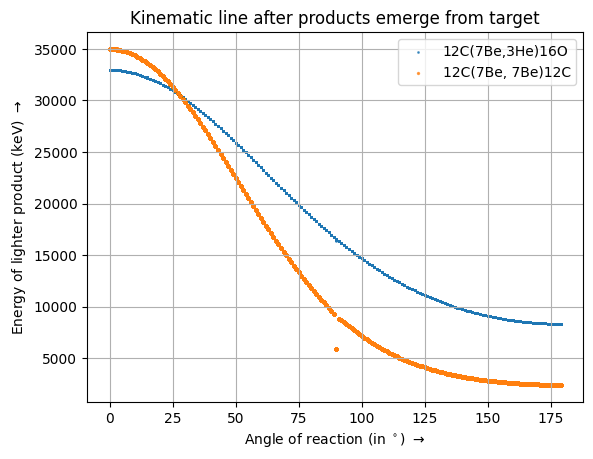

In [10]:
# plotting
plt.scatter(angles.flatten(), delE2_left.flatten(), s=1, alpha=0.7, label=name1)
plt.scatter(angles2.flatten(), delE2_left2.flatten(), s=2, alpha=0.7, label=name2)

plt.xlabel(r"Angle of reaction (in $^\circ$) $\rightarrow$")
plt.ylabel(r"Energy of lighter product (keV) $\rightarrow$")
plt.title("Kinematic line after products emerge from target")
plt.legend()
plt.grid()
plt.savefig("plot1.jpg")

## Detector material information

In [11]:
# Si info
Z_si=14
rho_si=2329.6
A_si=28


# Cs info
Z_Cs=55
rho_Cs=8960
A_Cs=132

# I info
Z_I=53
rho_I=7390
A_I=126

# Na info
Z_Na=13
rho_Na=9910
A_Na=22

# ionisation energy values:
I_nai=0.00764
I_Si= 0.0081517
I_csi=0.0071

## For Detector 1

In [12]:
Det=pd.read_excel(r"D:\nuclear\2_body_final_kin\2bodydetector.xlsx")


# detector info

d_t=Det["Detector Thickness"].to_numpy(dtype=np.float64) # in m
det_angle_open=Det["Detector angle_opening (theta>)"].to_numpy(dtype=np.float64) # in degrees
det_angle_close=Det["Detector angle_closing (theta<)"].to_numpy(dtype=np.float64) #in degrees
# to choose one detector from Si, CsI, NaI
det=Det["Detector Material"].to_numpy(dtype=np.float64)  # test
d_th=[]
for i in range(counts):
  d_theta = d_t / cos[i]
  d_th.append(d_theta)

In [13]:
# calculating energy loss in detector
abc=[]
delE3_left_J=[]
delE3_left=[]
delE2_left_J=np.array(delE2_left_J)

for i in range(0,counts):
  
    if (det==1): # Si detector
       
        delE3=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_si*rho_si*Na)/(M_u*A_si*2*delE2_left_J[i]))*np.log((4*delE2_left[i])/I_Si) # Cs


    if (det==2): # CsI detector
     
        delE3_1=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_Cs*rho_Cs*Na)/(M_u*A_Cs*2*delE2_left_J[i]))*np.log((4*delE2_left[i])/I_csi) # Cs
        delE3_2=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_I*rho_I*Na)/(M_u*A_I*2*delE2_left_J[i]))*np.log((4*delE2_left[i])/I_csi)  # I
        delE3=(A_Cs/(A_Cs+A_I))*delE3_1+(A_I/(A_Cs+A_I))*delE3_2

    if (det==3): # NaI detector
  
        delE3_1=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_Na*rho_Na*Na)/(M_u*A_Na*2*delE2_left_J[i]))*np.log((4*delE2_left[i])/I_nai) # Na
        delE3_2=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_I*rho_I*Na)/(M_u*A_I*2*delE2_left_J[i]))*np.log((4*delE2_left[i])/I_nai)  # I
        delE3=(A_Na/(A_Na+A_I))*delE3_1+(A_I/(A_Na+A_I))*delE3_2


    s2_in_J=delE2_left_J[i]-(delE3*d_th[i])
    s2=s2_in_J*6.242e+15
    delE3_left_J.append(s2_in_J)
    delE3_left.append(s2)
    abc.append(delE3*d_th[i]*6.242e+15)

## For Detector 2

In [14]:
Det2=pd.read_excel(r"D:\nuclear\2_body_final_kin\2bodydetector2.xlsx")


# detector info

d_t2=Det2["Detector Thickness"].to_numpy(dtype=np.float64) # in m
det_angle_open2=Det2["Detector angle_opening (theta>)"].to_numpy(dtype=np.float64) # in degrees
det_angle_close2=Det2["Detector angle_closing (theta<)"].to_numpy(dtype=np.float64) #in degrees
# to choose one detector from Si, CsI, NaI
det2=Det2["Detector Material"].to_numpy(dtype=np.float64)  # test
d_th2=[]
for i in range(counts):
  d_theta2 = d_t2 / cos[i]
  d_th2.append(d_theta2)

In [15]:
# calculating energy loss in detector
abc2=[]
delE3_left_J2=[]
delE3_left2=[]
delE2_left_J2=np.array(delE2_left_J2)

for i in range(0,counts):
  
    if (det==1): # Si detector
       
        delE32=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_si*rho_si*Na)/(M_u*A_si*2*delE2_left_J2[i]))*np.log((4*delE2_left2[i])/I_Si) # Cs


    if (det==2): # CsI detector
     
        delE3_12=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_Cs*rho_Cs*Na)/(M_u*A_Cs*2*delE2_left_J2[i]))*np.log((4*delE2_left2[i])/I_csi) # Cs
        delE3_22=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_I*rho_I*Na)/(M_u*A_I*2*delE2_left_J2[i]))*np.log((4*delE2_left2[i])/I_csi)  # I
        delE32=(A_Cs/(A_Cs+A_I))*delE3_12+(A_I/(A_Cs+A_I))*delE3_22

    if (det==3): # NaI detector
  
        delE3_12=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_Na*rho_Na*Na)/(M_u*A_Na*2*delE2_left_J2[i]))*np.log((4*delE2_left2[i])/I_nai) # Na
        delE3_22=((z_two*z_two*e*e*e*e)*(K*K))*((4*np.pi*Z_I*rho_I*Na)/(M_u*A_I*2*delE2_left_J2[i]))*np.log((4*delE2_left2[i])/I_nai)  # I
        delE32=(A_Na/(A_Na+A_I))*delE3_12+(A_I/(A_Na+A_I))*delE3_22


    s2_in_J2=delE2_left_J2[i]-(delE32*d_th2[i])
    s22=s2_in_J2*6.242e+15
    delE3_left_J2.append(s2_in_J2)
    delE3_left2.append(s22)
    abc2.append(delE32*d_th2[i]*6.242e+15)

## Final plotting

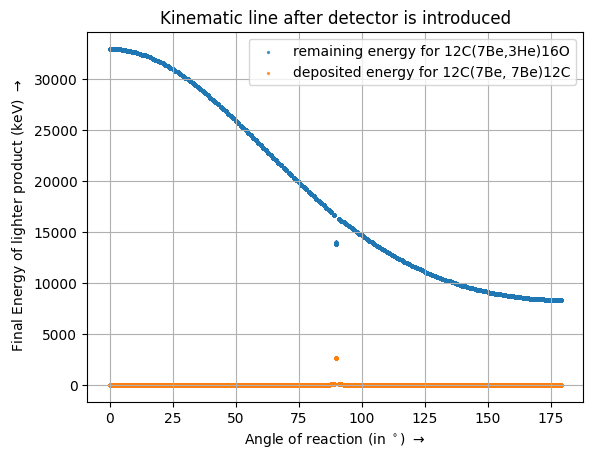

In [22]:
angles = np.array(angles)
delE3_left = np.array(delE3_left)
abc=np.array(abc)
# delE3_left2 = np.array(delE3_left2)
# abc2=np.array(abc2)

plt.scatter(angles.flatten(), delE3_left.flatten(), s=2, alpha=0.7, label=f"remaining energy for {name1}")
plt.scatter(angles.flatten(), abc.flatten(), s=2, alpha=0.7, label=f"deposited energy for {name2}")

# plt.scatter(angles.flatten(), delE3_left2.flatten(), s=2, alpha=0.7, label="remaining energy for reaction 2")
# plt.scatter(angles.flatten(), abc2.flatten(), s=2, alpha=0.7, label="deposited energy for reaction 2")
plt.xlabel(r"Angle of reaction (in $^\circ$) $\rightarrow$")
plt.ylabel(r" Final Energy of lighter product (keV) $\rightarrow$")
plt.title("Kinematic line after detector is introduced")
plt.legend()
plt.grid()
plt.savefig("plot2.jpg")
plt.legend()
# mask = (angles >= det_angle_open) & (angles <= det_angle_close)
# plt.scatter(angles[mask], delE3_left[i][mask], s=1)